In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print('Shape:', df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Duplicates ---')
print('Duplicate rows:', df.duplicated().sum())

--- Data Types ---
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

--- Missing Values ---
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

--- Duplicates ---
Duplicate rows: 0


In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

print('After cleaning — Shape:', df.shape)
print('Missing values remaining:', df.isnull().sum().sum())

After cleaning — Shape: (2640, 12)
Missing values remaining: 0


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


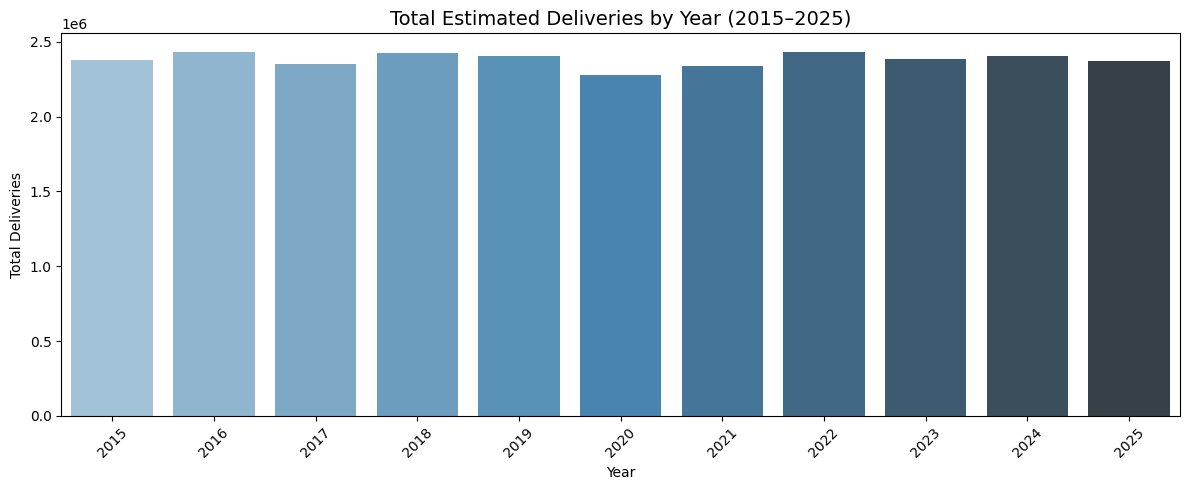

In [7]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=yearly, x='Year', y='Estimated_Deliveries', palette='Blues_d')
plt.title('Total Estimated Deliveries by Year (2015–2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

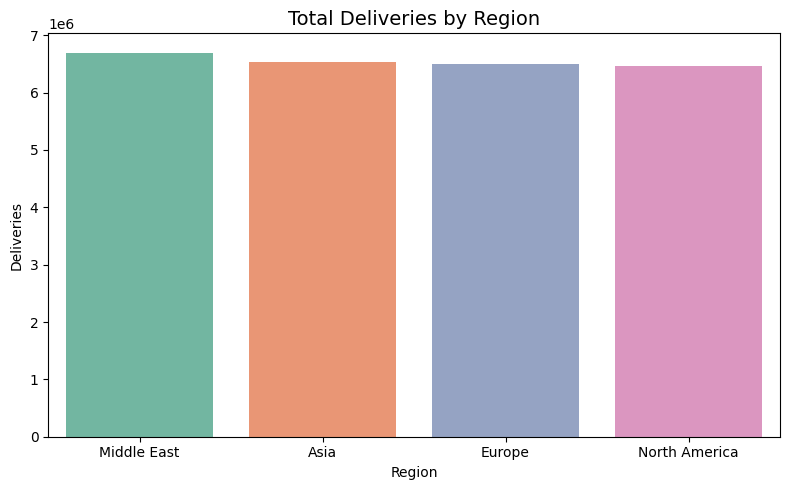

In [8]:
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().reset_index().sort_values('Estimated_Deliveries', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=region_del, x='Region', y='Estimated_Deliveries', palette='Set2')
plt.title('Total Deliveries by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

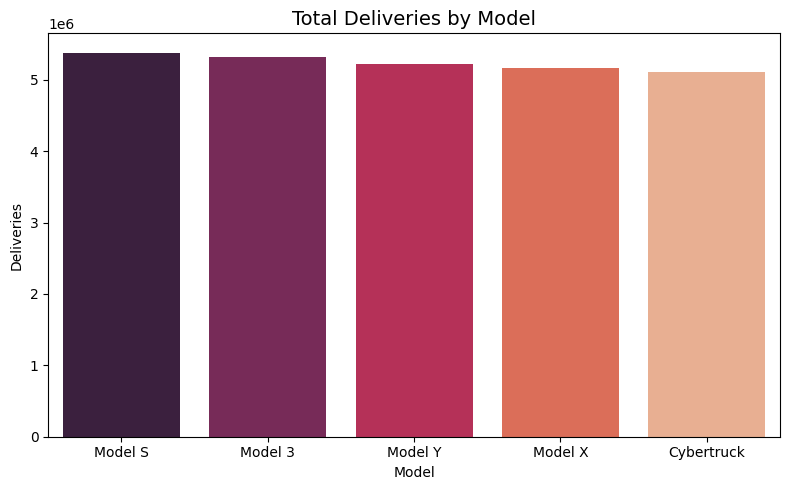

In [9]:
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().reset_index().sort_values('Estimated_Deliveries', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=model_del, x='Model', y='Estimated_Deliveries', palette='rocket')
plt.title('Total Deliveries by Model', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

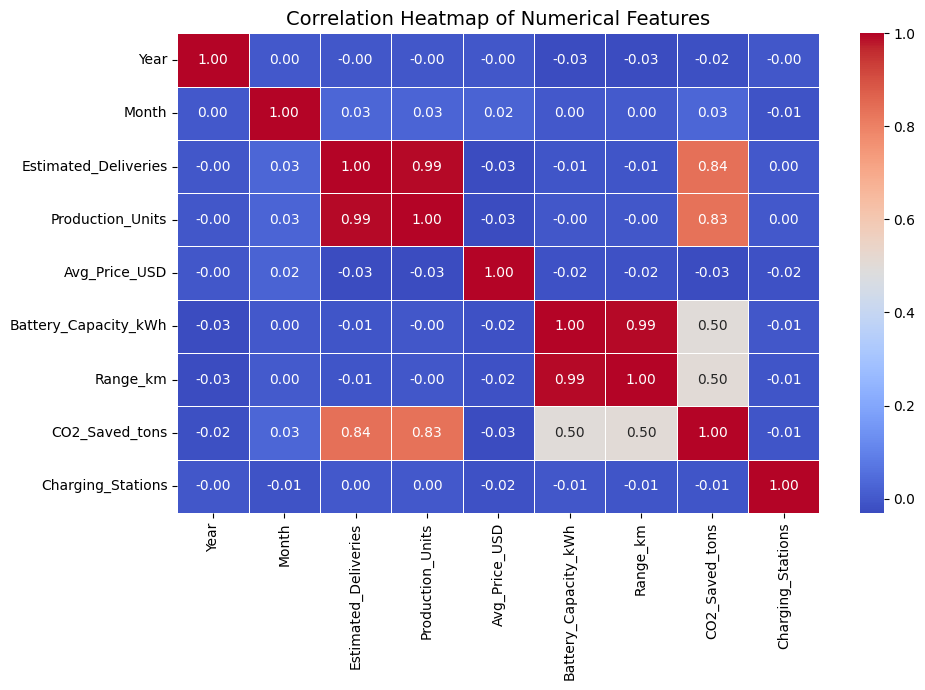

In [10]:
plt.figure(figsize=(10,7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

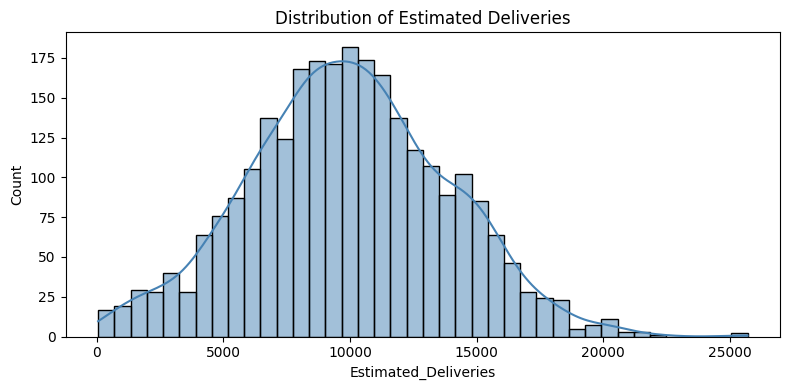

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df['Estimated_Deliveries'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Estimated Deliveries')
plt.tight_layout()
plt.show()

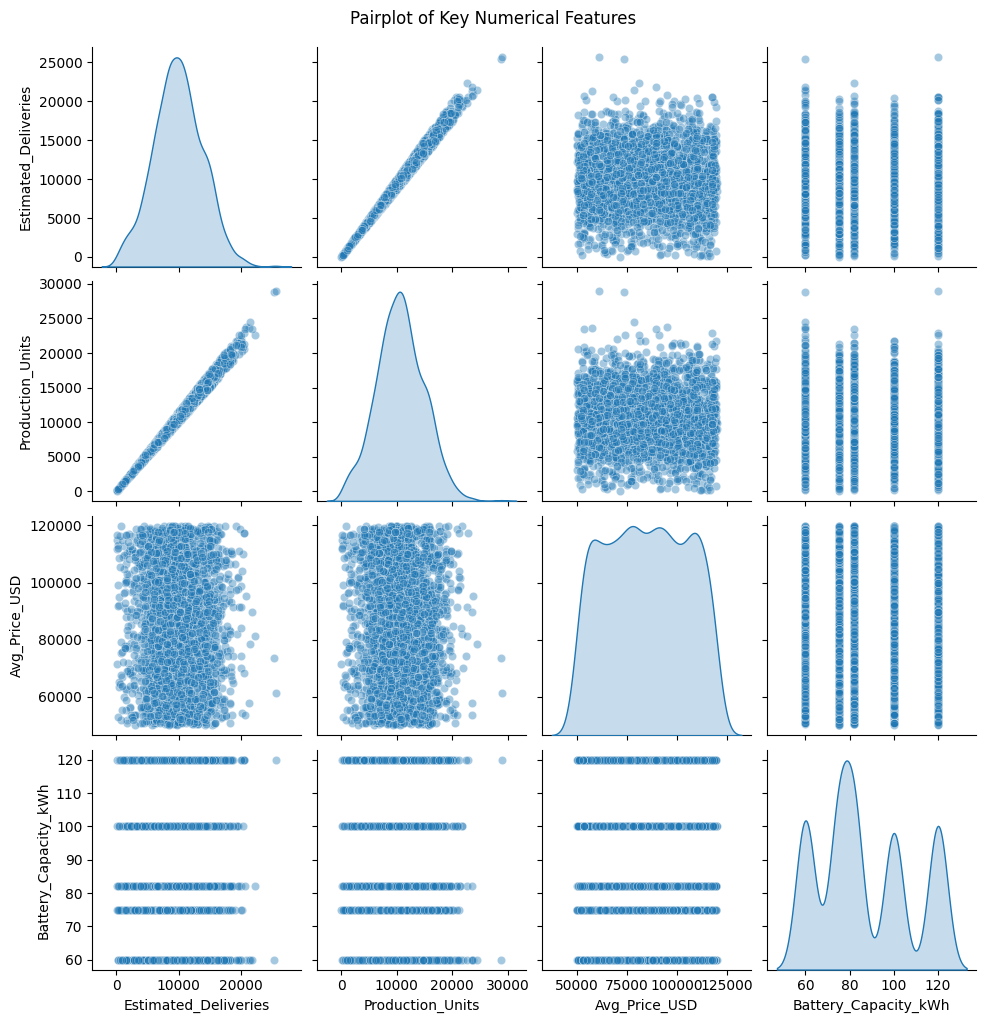

In [12]:
key_cols = ['Estimated_Deliveries'] + [c for c in num_cols if c not in ['Year','Month','Estimated_Deliveries']][:3]
sns.pairplot(df[key_cols], diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

df_fe = df.copy()

# ── Date Features ──────────────────────────────────────────────────────────
df_fe['Quarter'] = ((df_fe['Month'] - 1) // 3) + 1
df_fe['Is_Q4']   = (df_fe['Quarter'] == 4).astype(int)
df_fe['YearMonth'] = df_fe['Year'] * 100 + df_fe['Month']   # ordinal time index

# ── Cyclical Encoding for Month ────────────────────────────────────────────
df_fe['Month_sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)

# ── Label Encoding for Categoricals ───────────────────────────────────────
le = LabelEncoder()
for col in cat_cols:
    df_fe[col + '_enc'] = le.fit_transform(df_fe[col])

# ── Rolling Average (lag feature proxy) ───────────────────────────────────
df_fe = df_fe.sort_values(['Year','Month'])
df_fe['Delivery_RollMean3'] = df_fe['Estimated_Deliveries'].rolling(window=3, min_periods=1).mean()

print('New features added:', [c for c in df_fe.columns if c not in df.columns])
df_fe.head()

New features added: ['Quarter', 'Is_Q4', 'YearMonth', 'Month_sin', 'Month_cos', 'Region_enc', 'Model_enc', 'Source_Type_enc', 'Delivery_RollMean3']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Charging_Stations,Quarter,Is_Q4,YearMonth,Month_sin,Month_cos,Region_enc,Model_enc,Source_Type_enc,Delivery_RollMean3
644,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,...,5991,1,0,201501,0.5,0.866025,2,4,0,10348.000000
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,...,4390,1,0,201501,0.5,0.866025,0,4,2,11397.000000
904,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,...,12301,1,0,201501,0.5,0.866025,1,4,2,11209.666667
1199,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,...,9297,1,0,201501,0.5,0.866025,3,3,2,10467.666667
1228,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,...,8666,1,0,201501,0.5,0.866025,2,2,2,10953.000000


In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Feature Selection ──────────────────────────────────────────────────────
feature_cols = [
    'Year', 'Month', 'Quarter', 'Is_Q4',
    'Month_sin', 'Month_cos', 'Delivery_RollMean3'
] + [c for c in df_fe.columns if c.endswith('_enc')] \
  + [c for c in num_cols if c not in ['Year','Month','Estimated_Deliveries']]

# Keep only columns that actually exist
feature_cols = [c for c in feature_cols if c in df_fe.columns]

X = df_fe[feature_cols]
y = df_fe['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape} | Test size: {X_test.shape}')

Train size: (2112, 16) | Test size: (528, 16)


In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

print('=== Ridge Regression ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_ridge):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_ridge):.4f}')

=== Ridge Regression ===
MAE  : 310.86
RMSE : 386.83
R²   : 0.9906


In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_rf):.4f}')

=== Random Forest ===
MAE  : 324.69
RMSE : 456.83
R²   : 0.9869


In [17]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('=== Gradient Boosting ===')
print(f'MAE  : {mean_absolute_error(y_test, y_pred_gb):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}')
print(f'R²   : {r2_score(y_test, y_pred_gb):.4f}')

=== Gradient Boosting ===
MAE  : 324.44
RMSE : 429.31
R²   : 0.9884


In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print('Best Params:', grid_search.best_params_)
print('Best CV R²:', round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f'\nTuned RF → MAE: {mean_absolute_error(y_test, y_pred_best):.2f} | R²: {r2_score(y_test, y_pred_best):.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.9884

Tuned RF → MAE: 322.59 | R²: 0.9873


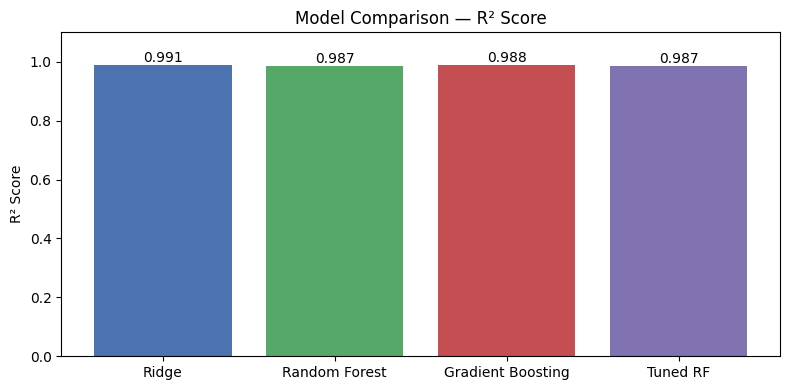

In [19]:
models = ['Ridge', 'Random Forest', 'Gradient Boosting', 'Tuned RF']
r2_scores = [
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb),
    r2_score(y_test, y_pred_best)
]

plt.figure(figsize=(8,4))
bars = plt.bar(models, r2_scores, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.ylim(0, 1.1)
plt.ylabel('R² Score')
plt.title('Model Comparison — R² Score')
for bar, val in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

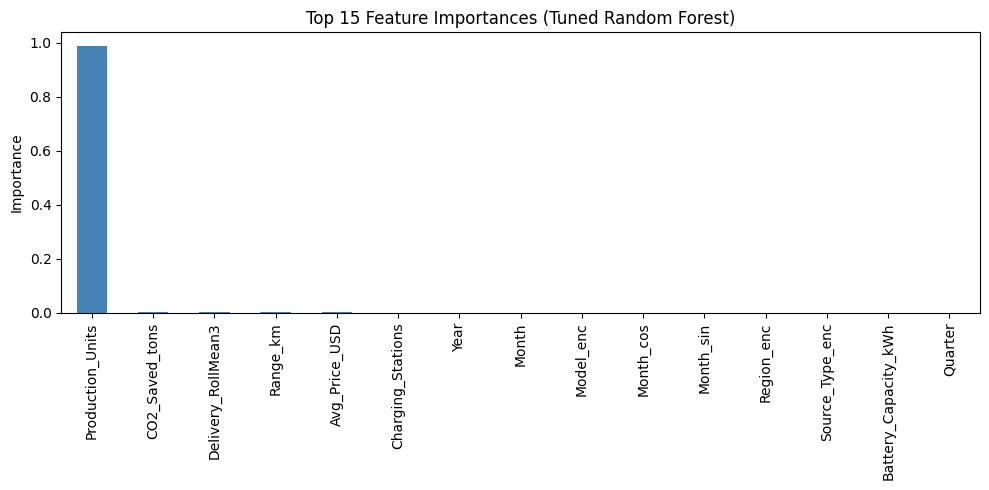

In [20]:
feat_imp = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances (Tuned Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

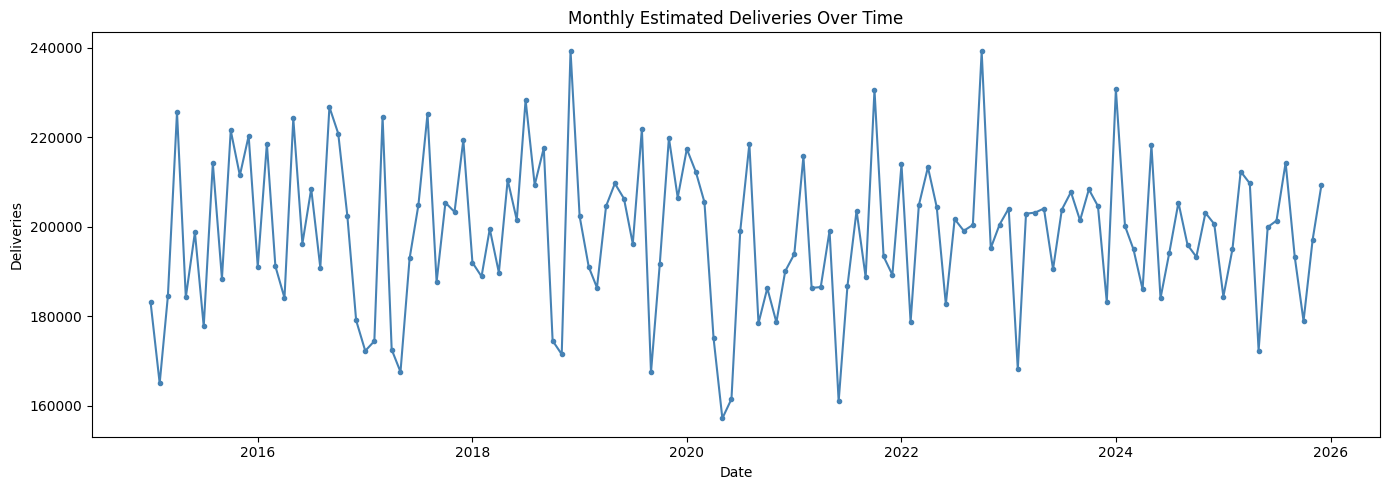

In [21]:
ts = df.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
ts['Date'] = pd.to_datetime(ts[['Year','Month']].assign(day=1))
ts = ts.sort_values('Date').set_index('Date')
ts_series = ts['Estimated_Deliveries']

plt.figure(figsize=(14,5))
plt.plot(ts_series, marker='o', markersize=3, linewidth=1.5, color='steelblue')
plt.title('Monthly Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.tight_layout()
plt.show()

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# ADF Test for stationarity
adf_result = adfuller(ts_series)
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print('Stationary    :', 'Yes' if adf_result[1] < 0.05 else 'No (may need differencing)')

ADF Statistic : -8.8810
p-value       : 0.0000
Stationary    : Yes


In [26]:
train_ts = ts_series[:-12]
test_ts  = ts_series[-12:]
ts_series = ts['Estimated_Deliveries'].asfreq('MS')

sarima_model = SARIMAX(
    train_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1061.796
Date:                            Sat, 06 Jun 2026   AIC                           2133.592
Time:                                    16:47:13   BIC                           2146.255
Sample:                                01-01-2015   HQIC                          2138.705
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0225      0.183      0.123      0.902      -0.337       0.382
ma.L1         -0.7136      0.098   

=== SARIMA Forecast Metrics ===
MAE  : 15247.47
RMSE : 19002.18
R²   : -1.1817


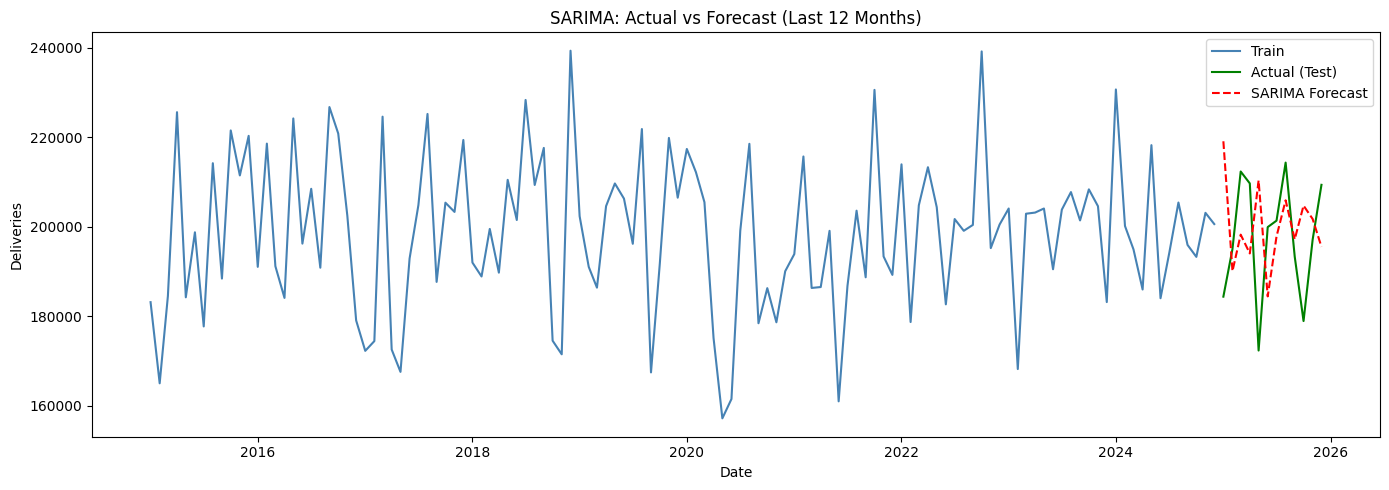

In [27]:
forecast = sarima_fit.forecast(steps=12)
forecast.index = test_ts.index

print('=== SARIMA Forecast Metrics ===')
print(f'MAE  : {mean_absolute_error(test_ts, forecast):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(test_ts, forecast)):.2f}')
print(f'R²   : {r2_score(test_ts, forecast):.4f}')

plt.figure(figsize=(14,5))
plt.plot(train_ts, label='Train', color='steelblue')
plt.plot(test_ts,  label='Actual (Test)', color='green')
plt.plot(forecast, label='SARIMA Forecast', color='red', linestyle='--')
plt.title('SARIMA: Actual vs Forecast (Last 12 Months)')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

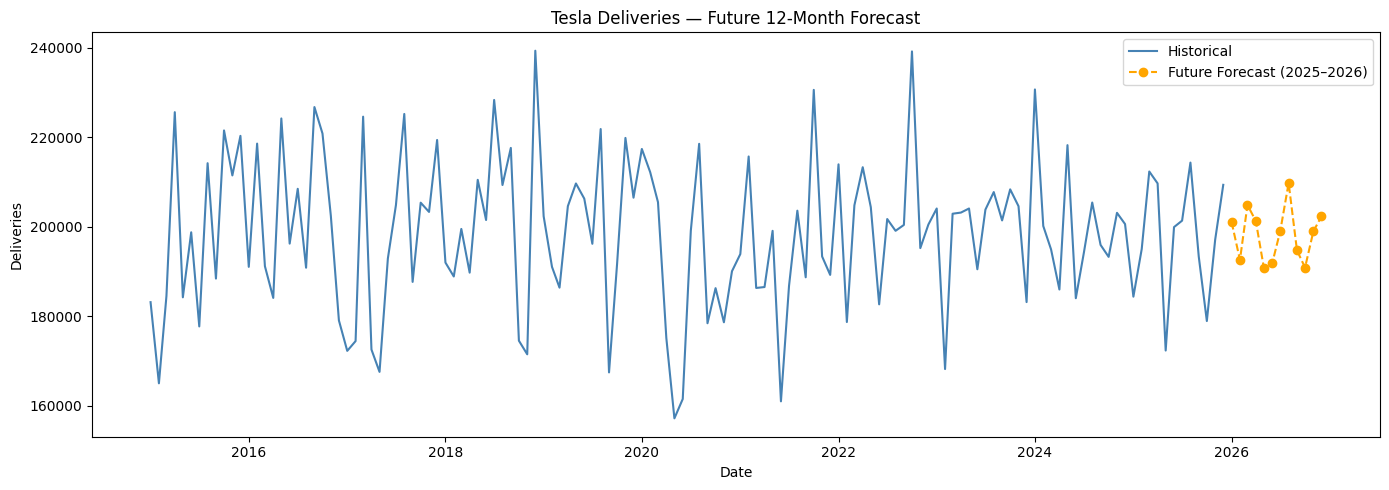


Forecasted Monthly Deliveries:
2026-01-01    201096.0
2026-02-01    192608.0
2026-03-01    204893.0
2026-04-01    201319.0
2026-05-01    190842.0
2026-06-01    191864.0
2026-07-01    199112.0
2026-08-01    209791.0
2026-09-01    194750.0
2026-10-01    190906.0
2026-11-01    199006.0
2026-12-01    202352.0
Freq: MS, Name: predicted_mean, dtype: float64


In [28]:
future_model = SARIMAX(
    ts_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_forecast = future_model.forecast(steps=12)

plt.figure(figsize=(14,5))
plt.plot(ts_series, label='Historical', color='steelblue')
plt.plot(future_forecast, label='Future Forecast (2025–2026)', color='orange', linestyle='--', marker='o')
plt.title('Tesla Deliveries — Future 12-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

print('\nForecasted Monthly Deliveries:')
print(future_forecast.round(0))